In [ ]:
# ==========================================
# 1. MONTAR GOOGLE DRIVE
# ==========================================

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
gpus = tf.config.list_physical_devices('GPU')
    print("GPUs disponibles:", gpus)
    if gpus:
        try:
            # Permite crecimiento de memoria para evitar asignación completa
            tf.config.experimental.set_memory_growth(gpus[0], True)
            print("Memory growth habilitado en GPU")
        except RuntimeError as e:
            print(f"No se pudo habilitar memory growth: {e}")

## 0. Resumen del recurso usado para el entrenamiento
- **Nombre**: *CheXmask Database: a large-scale dataset of anatomical segmentation masks for chest X-ray images*.  
- **Versión**: 1.0.0 (22 ene 2025).  
- **Tamaño**: ≈ 37 GB sin comprimir (CSV + máscaras en RLE).  
- **Contenido clave**  
  - **657 566** máscaras anatómicas (pulmón izq., pulmón der., corazón).  
  - Calidad estimada para cada máscara mediante **Dice‐RCA (mean / max)**.  
  - Licencia **CC-BY 4.0** . :contentReference[oaicite:0]{index=0}  

## 1. Configuración
- **Hiperparámetros**  
  `BACKBONE = 'resnet34'`, `IMG_SIZE = 256×256`, `BATCH = 8`, `EPOCHS = 25`, `THRESHOLD = 0.5`.
- **Rutas**  
  - Dataset anotado `LUNG_ROOT` (imágenes + máscaras).  
  - Dataset objetivo sin máscaras `CHEST_ROOT` (splits `train/val/test`, clases `NORMAL/PNEUMONIA`).  
  - Carpeta de salida de las nuevas máscaras `OUT_ROOT_V2`.

---

## 2. Preparación de datos
1. **Filtrado**  
   - Se listan PNGs de imágenes y máscaras, se cruzan por nombre base ⇒ solo pares válidos.  
2. **Generator** (`LungSequence`)  
   - Lee cada imagen en escala de grises → RGB → redimensiona a 256².  
   - Normaliza con el *pre-processing* oficial del backbone.  
   - La máscara se binariza y ajusta a la misma resolución.

---

## 3. División *train / val*
```python
train_test_split(... test_size = 0.2, random_state = 42)


In [4]:

import tensorflow as tf
if __name__ == "__main__":
    tf.debugging.set_log_device_placement(True)
    tf.debugging.set_log_device_placement(False)
    # -----------------------------------------------------------------------------
    gpus = tf.config.list_physical_devices('GPU')
    print("GPUs disponibles:", gpus)
    if gpus:
        try:
            # Permite crecimiento de memoria para evitar asignación completa
            tf.config.experimental.set_memory_growth(gpus[0], True)
            print("Memory growth habilitado en GPU")
        except RuntimeError as e:
            print(f"No se pudo habilitar memory growth: {e}")

GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Memory growth habilitado en GPU


In [42]:

# ---------------------------------------------------------
# 0) Importaciones y monkey‐patch para segmentation_models
# ---------------------------------------------------------
import os
import cv2
import numpy as np
from glob import glob
from sklearn.model_selection import train_test_split

import keras
import tensorflow as tf
# parche para get_custom_objects
from tensorflow.keras.utils import get_custom_objects as _gco
import keras.utils.generic_utils as generic_utils
generic_utils.get_custom_objects = _gco

import segmentation_models as sm
sm.set_framework('tf.keras')
sm.framework()

# ---------------------------------------------------------
# 1) Hiperparámetros y rutas
# ---------------------------------------------------------
BACKBONE    = 'resnet34'
IMG_SIZE    = (256,256)
BATCH       = 8
EPOCHS      = 25
THRESHOLD   = 0.5

# Ground‐truth masks en tu carpeta “Lung Segmentation”
LUNG_ROOT   = '/workspace/data/Lung Segmentation'
IMG_DIR     = os.path.join(LUNG_ROOT, 'images')
MASK_DIR    = os.path.join(LUNG_ROOT, 'masks')

# Cargamos y filtramos solo los pares imagen–máscara coincidentes
txt_imgs  = sorted(glob(os.path.join(IMG_DIR, '*.png')))
raw_masks = sorted(glob(os.path.join(MASK_DIR, '*.png')))
# Extraemos nombres base (sin extensión)
img_bases  = {os.path.splitext(os.path.basename(p))[0] for p in raw_imgs}
mask_bases = {os.path.splitext(os.path.basename(p))[0] for p in raw_masks}
# Intersección de conjuntos para pares válidos
common     = sorted(img_bases & mask_bases)
# Rutas finales de imágenes y máscaras
LUNG_IMGS   = [os.path.join(IMG_DIR, f + '.png') for f in common]
LUNG_MASKS  = [os.path.join(MASK_DIR, f + '.png') for f in common]

# Dataset CXR
CHEST_ROOT  = '/workspace/data/chest_xray'
# Carpeta de salida V2
OUT_ROOT_V2 = '/workspace/data/chest_xray_masks_V2'
for split in ['train','val','test']:
    for cls in ['NORMAL','PNEUMONIA']:
        os.makedirs(os.path.join(OUT_ROOT_V2, split, cls), exist_ok=True)

# ---------------------------------------------------------
# 2) Data generator para entrenamiento
# ---------------------------------------------------------
preprocess_input = sm.get_preprocessing(BACKBONE)

def load_pair(img_path, mask_path):
    img  = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    img  = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    img  = cv2.resize(img, IMG_SIZE)
    mask = cv2.resize(mask, IMG_SIZE)
    mask = (mask > 127).astype('float32')[...,None]
    img  = preprocess_input(img)
    return img, mask

class LungSequence(tf.keras.utils.Sequence):
    def __init__(self, imgs, masks, batch_size=BATCH):
        self.imgs  = imgs
        self.masks = masks
        self.batch = batch_size
    def __len__(self):
        return len(self.imgs)//self.batch
    def __getitem__(self, idx):
        batch_i = self.imgs [idx*self.batch:(idx+1)*self.batch]
        batch_m = self.masks[idx*self.batch:(idx+1)*self.batch]
        X, Y    = zip(*(load_pair(i, m) for i, m in zip(batch_i, batch_m)))
        return np.array(X), np.array(Y)

# ---------------------------------------------------------
# 3) Split train / val en el dataset filtrado
# ---------------------------------------------------------
train_i, val_i, train_m, val_m = train_test_split(
    LUNG_IMGS, LUNG_MASKS,
    test_size=0.2, random_state=42
)
train_gen = LungSequence(train_i, train_m)
val_gen   = LungSequence(val_i,   val_m)

# ---------------------------------------------------------
# 4) Definición y compilación del modelo U-Net
# ---------------------------------------------------------
model = sm.Unet(
    BACKBONE,
    encoder_weights='imagenet',
    input_shape=(*IMG_SIZE, 3),
    classes=1,
    activation='sigmoid'
)
model.compile(
    optimizer='adam',
    loss=sm.losses.bce_jaccard_loss,
    metrics=[sm.metrics.iou_score]
)

# ---------------------------------------------------------
# 5) Callbacks y entrenamiento
# ---------------------------------------------------------
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=5, restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'lung_unet_v2.h5', save_best_only=True
    )
]
model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)

# ---------------------------------------------------------
# 6) Inferencia y guardado de máscaras V2
# ---------------------------------------------------------
def predict_folder(in_dir, out_dir):
    for f in os.listdir(in_dir):
        if not f.lower().endswith(('.png','jpg','jpeg')):
            continue
        img0 = cv2.imread(os.path.join(in_dir, f), cv2.IMREAD_GRAYSCALE)
        rgb  = cv2.cvtColor(img0, cv2.COLOR_GRAY2RGB)
        small = cv2.resize(rgb, IMG_SIZE)
        x = preprocess_input(small)[None,...]
        pred = model.predict(x)[0,:,:,0]
        mask = (pred > THRESHOLD).astype('uint8') * 255
        mask = cv2.resize(
            mask,
            (img0.shape[1], img0.shape[0])
        )
        cv2.imwrite(os.path.join(out_dir, f), mask)

for split in ['train', 'val', 'test']:
    for cls in ['NORMAL', 'PNEUMONIA']:
        inp = os.path.join(CHEST_ROOT, split, cls)
        out = os.path.join(OUT_ROOT_V2, split, cls)
        print(f'Inferiendo {inp} → {out}')
        predict_folder(inp, out)

print('✅ ¡Terminó! Todas las máscaras V2 están en data/chest_xray_masks_V2/')


Epoch 1/25


2025-07-06 18:46:29.437987: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


13/13 [==============================] - ETA: 0s - loss: 0.8652 - iou_score: 0.4405

2025-07-06 18:46:57.636715: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


13/13 [==============================] - 33s 2s/step - loss: 0.8652 - iou_score: 0.4405 - val_loss: 4.5704 - val_iou_score: 0.3878
Epoch 2/25
13/13 [==============================] - 21s 2s/step - loss: 0.4039 - iou_score: 0.7106 - val_loss: 5.4265 - val_iou_score: 0.4056
Epoch 3/25
13/13 [==============================] - 22s 2s/step - loss: 0.2493 - iou_score: 0.8229 - val_loss: 2.3683 - val_iou_score: 0.4580
Epoch 4/25
13/13 [==============================] - 22s 2s/step - loss: 0.1651 - iou_score: 0.8842 - val_loss: 1.0116 - val_iou_score: 0.5620
Epoch 5/25
13/13 [==============================] - 21s 2s/step - loss: 0.1303 - iou_score: 0.9106 - val_loss: 1.1029 - val_iou_score: 0.5557
Epoch 6/25
13/13 [==============================] - 22s 2s/step - loss: 0.1243 - iou_score: 0.9181 - val_loss: 0.6713 - val_iou_score: 0.6777
Epoch 7/25
13/13 [==============================] - 22s 2s/step - loss: 0.1020 - iou_score: 0.9317 - val_loss: 0.4499 - val_iou_score: 0.7553
Epoch 8/25
13/13 

In [43]:
# ---------------------------------------------------------
# 6) Guardar modelo entrenado
# ---------------------------------------------------------
model.save('lung_unet_v2-_external_final.h5')
print('🔖 Modelo guardado en lung_unet_v2-_external_final.h5')


🔖 Modelo guardado en lung_unet_v2_final.h5


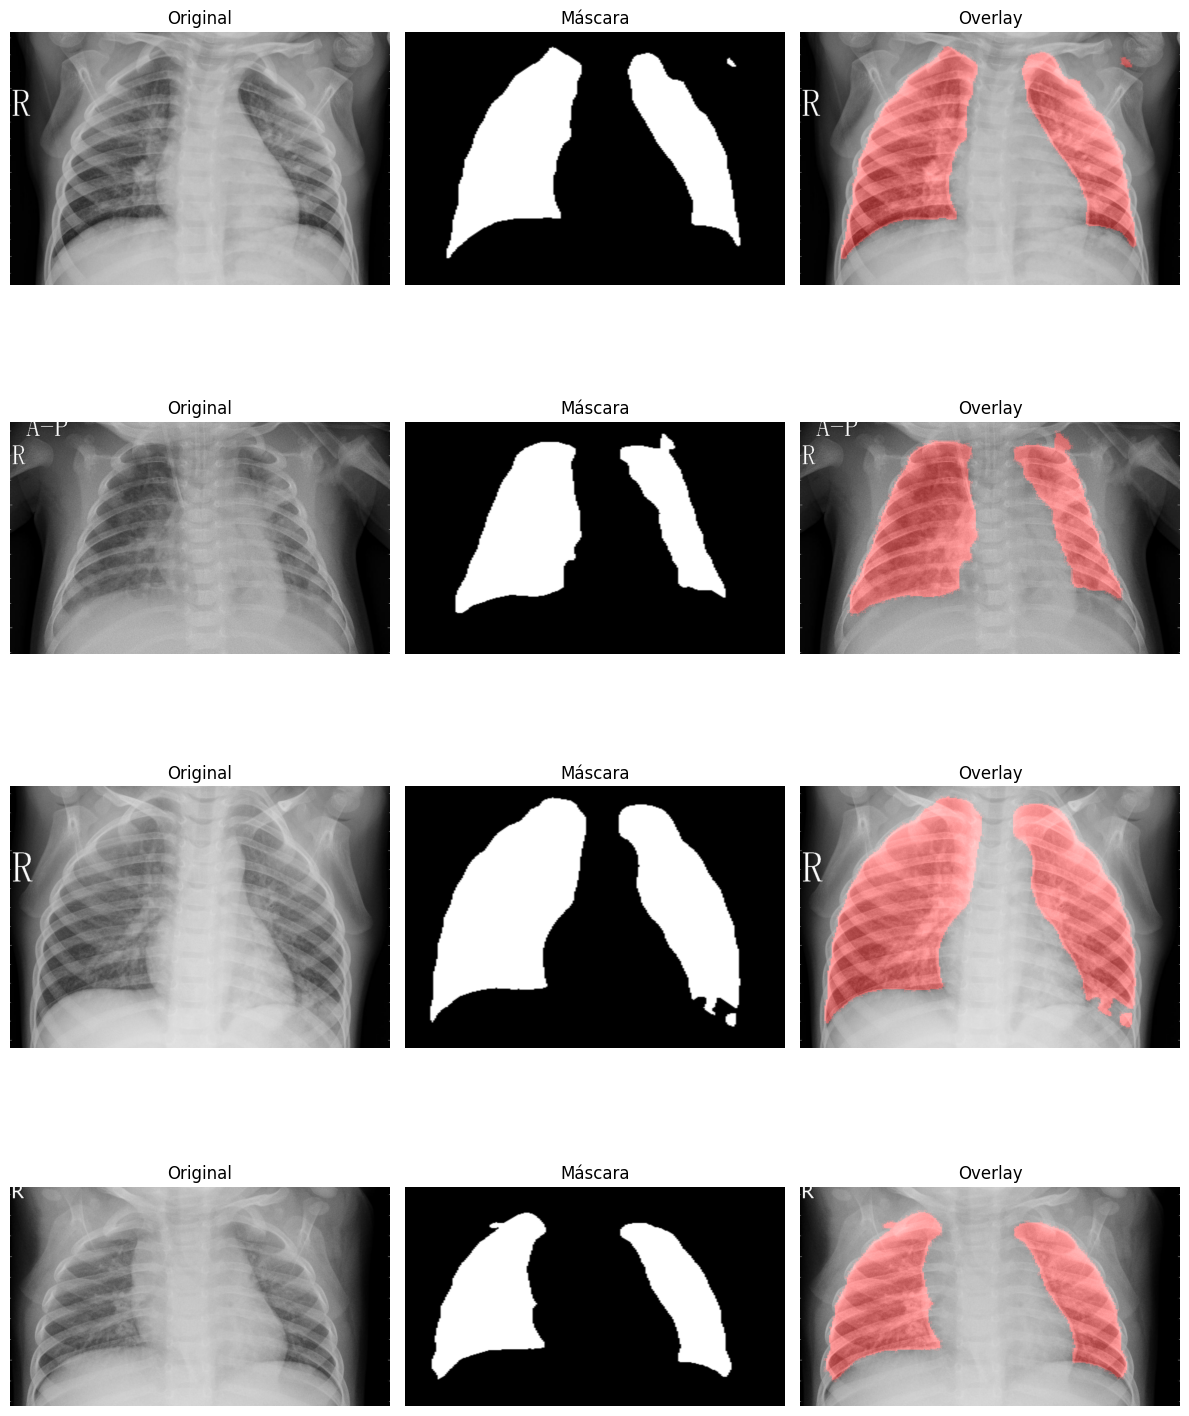

In [49]:
# ---------------------------------------------------------
# 0) True → Google Drive  |  False → local
# ---------------------------------------------------------
USE_DRIVE = True      

if USE_DRIVE:
    # Colab: monta tu Google Drive
    from google.colab import drive
    drive.mount('/content/drive')

    # Ruta base dentro de Drive 
    BASE_DIR = '/content/drive/MyDrive/Capstone/data/'
else:
    # Ruta base local (
    BASE_DIR = '/workspace/data'         

# Directorios comunes
CHEST_ROOT  = os.path.join(BASE_DIR, 'chest_xray')
OUT_ROOT_V2 = os.path.join(BASE_DIR, 'chest_xray_masks_V2')

# ---------------------------------------------------------
# 1) Función de overlay y visualización aleatoria
# ---------------------------------------------------------
import os, cv2, random, numpy as np
import matplotlib.pyplot as plt

def overlay_mask(img_bgr, mask_gray, alpha=0.4, color=(0, 0, 255)):
    """Superpone una máscara binaria sobre la imagen BGR."""
    colored = np.zeros_like(img_bgr, dtype=np.uint8)
    colored[mask_gray > 0] = color
    return cv2.addWeighted(img_bgr, 1.0, colored, alpha, 0)

# ----------- elige split y clase a mostrar -----------
spl, cls = 'val', 'PNEUMONIA'

orig_dir = os.path.join(CHEST_ROOT, spl, cls)
pred_dir = os.path.join(OUT_ROOT_V2, spl, cls)

files = [f for f in os.listdir(orig_dir)
         if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

n = len(files)
if n == 0:
    raise RuntimeError(f"No se encontraron imágenes en {orig_dir}")

k = min(4, n)                    # muestra hasta 4 ejemplos
sample = random.sample(files, k=k)

# ----------- grid k × 3  (original | máscara | overlay) ---------
fig, axs = plt.subplots(k, 3, figsize=(12, 4 * k))

for i, fname in enumerate(sample):
    img  = cv2.imread(os.path.join(orig_dir, fname))
    mask = cv2.imread(os.path.join(pred_dir, fname), cv2.IMREAD_GRAYSCALE)
    over = overlay_mask(img, mask, alpha=0.4)

    axs[i, 0].imshow(cv2.cvtColor(img,  cv2.COLOR_BGR2RGB))
    axs[i, 0].axis('off'); axs[i, 0].set_title('Original')

    axs[i, 1].imshow(mask, cmap='gray')
    axs[i, 1].axis('off'); axs[i, 1].set_title('Máscara')

    axs[i, 2].imshow(cv2.cvtColor(over, cv2.COLOR_BGR2RGB))
    axs[i, 2].axis('off'); axs[i, 2].set_title('Overlay')

plt.tight_layout()
plt.show()
